In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys

import jax
import jax.numpy as jnp

import numpy as np
import healpy as hp
import pickle
from tqdm import tqdm

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

[gpu(id=0)]


In [2]:
sys.path.append("..")
from models.np_model import NPModel
from simulations.wrapper import simulator_for_model
from models.scd import dnds
from models.psf import KingPSF

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## NP: Sps tempates, flat exposures

In [3]:
npmodel = NPModel(
    non_poissonian=True,
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
    use_flat_exposure=True,
)

Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/npll_issue/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [4]:
base_var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0., S_bub = 0., S_psc = 0., S_pib = 0., S_ics = 0.,
    S_gce = 0., gamma_poiss = 0.9, f_bulge_poiss = 0.00001,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
    theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
    Sps_gce = None, gamma_ps = 1.2, f_bulge_ps = 0.00001,
    Sps_dsk = None, zs = 0.5, C = 2.5,
    Sps_iso = None,
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
    n1_iso = 5.5, n2_iso = 1.5, n3_iso = -5.5, sb1_iso = 7.6, lambdas_iso = 0.3, # identical to gce
    Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
)

In [5]:
save_dir = "dsk_gce_kingpsf"
os.makedirs(save_dir, exist_ok=True)
var_dict = base_var_dict.copy()
var_dict['Sps_dsk'] = 1.
var_dict['Sps_gce'] = 2.
var_dict['Sps_iso'] = 0.
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:3662: UserWarning: 'kind' argument to argsort is ignored; only 'stable' sorts are supported.
  warnings.warn("'kind' argument to argsort is ignored; only 'stable' sorts "


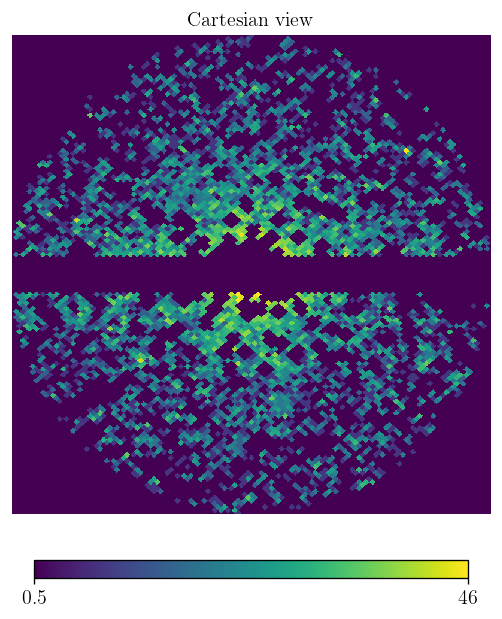

In [8]:
# preview
counts = simulator_for_model(npmodel, var_dict, no_psc_mask=True, delta_psf=False, no_plane_mask=False)
hp.cartview(np.clip(counts, 0.5, None), norm='log', latra=[-25., 25.], lonra=[-25., 25.])

In [6]:
# simulate
data_s = []
for i in tqdm(range(30)):
    counts = simulator_for_model(npmodel, var_dict, no_psc_mask=False, delta_psf=False, no_plane_mask=False)
    data_s.append(counts)
np.save(f"{save_dir}/data.npy", np.array(data_s, dtype=np.int32))

  0%|          | 0/30 [00:00<?, ?it/s]/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:3662: UserWarning: 'kind' argument to argsort is ignored; only 'stable' sorts are supported.
  warnings.warn("'kind' argument to argsort is ignored; only 'stable' sorts "
100%|██████████| 30/30 [04:43<00:00,  9.45s/it]


## Check mean

In [7]:
mean_arr = []
for i in range(50):
    counts = np.load(f"{save_dir}/counts_{i}.npy")
    mean_arr.append(np.mean(counts[~npmodel.normalization_mask]))
plt.hist(mean_arr, bins=30)
print(np.mean(mean_arr), '+/-', np.std(mean_arr) / np.sqrt(len(mean_arr)))

FileNotFoundError: [Errno 2] No such file or directory: 'dsk_gce_kingpsf/counts_0.npy'

## input shape

In [12]:
from jax_ll import ll_justSps
vd = base_var_dict.copy()
vd['Sps_dsk'] = 1.
vd['Sps_gce'] = 2.
vd['Sps_iso'] = 0.
data = jnp.zeros(hp.nside2npix(npmodel.nside), dtype=np.int32)
ll_justSps(npmodel, vd, data)

mu (196608,)
8292
mu_masked (8292,)
npt_compressed_masked (2, 8292)
data_masked (8292,)
theta [[ 2.73608428e-02  5.50000000e+00  1.50000000e+00 -5.50000000e+00
   7.60000000e+00  2.28000000e+00]
 [ 8.83843416e-03  5.00000000e+00  1.30000000e+00 -5.40000000e+00
   1.10000000e+01  4.40000000e+00]]
m.f_ary (15,)
m.df_rho_div_f_ary (15,)
m.k_max 103
len(mu_masked) 8292


Array(-11386.78252729, dtype=float64)